<a href="https://colab.research.google.com/github/jiwonojo/Data-Capstone-Design---2026/blob/main/%ED%94%BC%EB%93%9C%EB%B0%B1_%EC%8B%9C%EA%B0%81%ED%99%94.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import matplotlib.pyplot as plt

plt.rc('font', family='NanumBarunGothic')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [ ]:
# =========================
# 0. 기본 설치 및 세팅
# =========================

!pip -q install wordcloud plotly scikit-learn

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import plotly.express as px
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation

# Colab 한글 폰트 설치
!apt-get -qq install fonts-nanum

import matplotlib.font_manager as fm
import matplotlib as mpl

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
font_name = fm.FontProperties(fname=font_path).get_name()
mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

In [ ]:
# =========================
# 1. 피드백 데이터 입력
# =========================

data = [
    {
        "name": "권노현",
        "feedback": "어떤 금융 거래 데이터인지 명확하지 못한 것 같습니다. 실제 금융패턴과 사기가 데이터셋에서 분류한 것과 다를 것 같고, 거래 채널에 대한 내용도 충분히 반영하지 못한것같습니다."
    },
    {
        "name": "기민서",
        "feedback": "발표 자료에서 팔로우하기 힘들었습니다. 자료를 중요한 부분을 키워서 잘 보이게 두면 이해하기 더 편할 것 같습니다."
    },
    {
        "name": "김정운",
        "feedback": "코드를 보여주고, 여러 지표들을 다 보여주기에 전달력에 대해 아쉽다고 생각이 들었습니다. 중심 내용을 골라서 보여준다면 전달력이 높아질 거 같습니다."
    },
    {
        "name": "김진우",
        "feedback": "최근 이슈가 많이 되는 사회적 주제여서 더 흥미롭게 발표 들었습니다. 다만 기존에 존재하는 서비스들과의 차이점이 명확히 보이지는않습니다. 또한 PPT에는 결과 위주로 들어가는 텍스트를 줄인다면 더 가독성이 높아질것 같습니다."
    },
    {
        "name": "김태곤",
        "feedback": "발표 잘 들었습니다. 현재 많은 이슈화가 되어있는 문제를 주제로 삼으셔서 흥미로웠습니다. ppt에 들어있는 내용들이 좋은 내용들도 많지만 너무 조금 많다는 생각이 듭니다. 조금 ppt 내용을 꼭 필수적인 내용만 담고 포인트 되는 부분만 깊게 설명을 했어도 충분했을 것 같습니다."
    },
    {
        "name": "박준희",
        "feedback": "PPT에는 중요한 정보만 담았으면 훨씬 가독성이 좋지 않았을까 싶습니다. 사기를 탐지하는 것이기에 Precision보다는 Recall이 훨씬 중요한 지표가 아닐까 싶습니다. 실제 사기를 사기가 아니라고 판단하는 빈도를 줄이는 것이 중요하다고 생각이 되는데, F1 score보다 F beta score를 사용해서 recall의 중요도를 더 높이는 것이 어떨까 생각이 됩니다."
    },
    {
        "name": "오찬세",
        "feedback": "금융 이상탐지 주제는 오래전부터 많이 해오던 주제로 알고 있는데, 기존의 주제와 어떠한 차이점이 있는지 궁금하고, 머신러닝 방법 말고도 또 다르게 생각한 방법이 있는지도 궁금합니다."
    },
    {
        "name": "이건우",
        "feedback": "두 변수를 데이터 leakage 의심 변수로 판단한 이유가 더 깊게 분석되었으면 어떨까 하는 궁금증이 들었어요. 발표 자료만으로는 바로 와닿지 않아서 조금 아쉬웠던 것 같아요. 이외에는 주제 자체가 흥미로워서 재미있게 들었던 것 같아요! 코드 캡쳐본 보다는 개념 위주로 설명해도 좋아보여요."
    },
    {
        "name": "이기원",
        "feedback": "최근 많이 대두되는 분야의 연구여서 재미있게 봤습니다. 기존에 연구되고 있는 또는 선행되어 연구되고 있는 경우는 어떤 파라미터를 썼는지, 지금 하시는 연구가 어떤 차이가 있는지에 대한 차별점을 얘기해주면 좋을 것 같습니다."
    },
    {
        "name": "이채경",
        "feedback": "비슷한 주재로 진행한 프로젝트도 있는걸로 알고 있는데, 다른 프로젝트와의 차별점이 있는지 궁금합니다."
    },
    {
        "name": "이하영",
        "feedback": "PPT 폰트 크기가 더 컸으면 좋았을 것 같습니다. 데이터 누수 의심 변수를 제거하셨다고 하셨는데, 정말로 데이터가 누수되는 건지 확인해봐도 좋을 것 같습니다. 정말로 데이터가 누수되는 게 아니라면 해당 변수를 제거할 이유가 없어보입니다."
    },
    {
        "name": "이호준",
        "feedback": "금융 범죄가 만연한 지금 필요한 프로젝트인거 같습니다. 다소 실제 현업에서 많이 진행되는 주제이다 보니 프로젝트의 차별점과 특별함이 무엇인지는 모르겠습니다."
    },
    {
        "name": "장준필",
        "feedback": "이상 거래 탐지 분야에서의 기존 모델과의 어떤 차별점이 있는지 궁금하고 2개의 모델만 실험해 본 점도 궁금합니다. 또한, 이상치 데이터에 대한 분석을 통해 feature를 설계하고 이를 반영한 모델 구축이 중요할 것 같습니다. 발표 잘 들었습니다!"
    }
]

df = pd.DataFrame(data)
df

,name,feedback
0,권노현,어떤 금융 거래 데이터인지 명확하지 못한 것 같습니다. 실제 금융패턴과 사기가 데이...
1,기민서,발표 자료에서 팔로우하기 힘들었습니다. 자료를 중요한 부분을 키워서 잘 보이게 두면...
2,김정운,"코드를 보여주고, 여러 지표들을 다 보여주기에 전달력에 대해 아쉽다고 생각이 들었습..."
3,김진우,최근 이슈가 많이 되는 사회적 주제여서 더 흥미롭게 발표 들었습니다. 다만 기존에 ...
4,김태곤,발표 잘 들었습니다. 현재 많은 이슈화가 되어있는 문제를 주제로 삼으셔서 흥미로웠습...
5,박준희,PPT에는 중요한 정보만 담았으면 훨씬 가독성이 좋지 않았을까 싶습니다. 사기를 탐...
6,오찬세,"금융 이상탐지 주제는 오래전부터 많이 해오던 주제로 알고 있는데, 기존의 주제와 어..."
7,이건우,두 변수를 데이터 leakage 의심 변수로 판단한 이유가 더 깊게 분석되었으면 어...
8,이기원,최근 많이 대두되는 분야의 연구여서 재미있게 봤습니다. 기존에 연구되고 있는 또는 ...
9,이채경,"비슷한 주재로 진행한 프로젝트도 있는걸로 알고 있는데, 다른 프로젝트와의 차별점이 ..."


In [ ]:
# =========================
# 2. 토픽 분류 기준 설정
# =========================

topic_keywords = {
    "PPT 가독성/구성": [
        "ppt", "PPT", "폰트", "가독성", "자료", "텍스트", "중요한 정보",
        "중요한 부분", "잘 보이게", "필수적인 내용", "포인트", "결과 위주"
    ],
    "발표 전달력": [
        "전달력", "팔로우", "이해", "중심 내용", "개념 위주", "코드 캡쳐본",
        "코드를 보여주고", "여러 지표"
    ],
    "차별성/기존 연구 비교": [
        "차이점", "차별점", "기존", "서비스", "선행", "연구", "현업",
        "특별함", "비슷한", "프로젝트"
    ],
    "데이터 설명/현실성": [
        "금융 거래 데이터", "데이터셋", "실제 금융패턴", "거래 채널",
        "어떤 금융 거래", "분류"
    ],
    "데이터 누수/변수 검증": [
        "leakage", "누수", "의심 변수", "제거", "변수", "이유",
        "정말로", "확인"
    ],
    "평가지표 개선": [
        "Precision", "Recall", "F1", "F beta", "score", "지표",
        "사기가 아니라고", "빈도"
    ],
    "모델링/피처 엔지니어링": [
        "모델", "머신러닝", "방법", "이상치", "feature", "설계",
        "파라미터", "구축", "분석"
    ],
    "주제 흥미/필요성": [
        "흥미", "재미있게", "이슈", "사회적 주제", "필요한 프로젝트",
        "금융 범죄", "주제 자체"
    ]
}

def classify_topics(text):
    matched_topics = []
    for topic, keywords in topic_keywords.items():
        if any(keyword in text for keyword in keywords):
            matched_topics.append(topic)
    return matched_topics

df["topics"] = df["feedback"].apply(classify_topics)
df["topic_count"] = df["topics"].apply(len)
df

,name,feedback,topics,topic_count
0,권노현,어떤 금융 거래 데이터인지 명확하지 못한 것 같습니다. 실제 금융패턴과 사기가 데이...,[데이터 설명/현실성],1
1,기민서,발표 자료에서 팔로우하기 힘들었습니다. 자료를 중요한 부분을 키워서 잘 보이게 두면...,"[PPT 가독성/구성, 발표 전달력]",2
2,김정운,"코드를 보여주고, 여러 지표들을 다 보여주기에 전달력에 대해 아쉽다고 생각이 들었습...","[발표 전달력, 평가지표 개선]",2
3,김진우,최근 이슈가 많이 되는 사회적 주제여서 더 흥미롭게 발표 들었습니다. 다만 기존에 ...,"[PPT 가독성/구성, 차별성/기존 연구 비교, 주제 흥미/필요성]",3
4,김태곤,발표 잘 들었습니다. 현재 많은 이슈화가 되어있는 문제를 주제로 삼으셔서 흥미로웠습...,"[PPT 가독성/구성, 주제 흥미/필요성]",2
5,박준희,PPT에는 중요한 정보만 담았으면 훨씬 가독성이 좋지 않았을까 싶습니다. 사기를 탐...,"[PPT 가독성/구성, 평가지표 개선]",2
6,오찬세,"금융 이상탐지 주제는 오래전부터 많이 해오던 주제로 알고 있는데, 기존의 주제와 어...","[차별성/기존 연구 비교, 모델링/피처 엔지니어링]",2
7,이건우,두 변수를 데이터 leakage 의심 변수로 판단한 이유가 더 깊게 분석되었으면 어...,"[PPT 가독성/구성, 발표 전달력, 데이터 누수/변수 검증, 모델링/피처 엔지니어...",5
8,이기원,최근 많이 대두되는 분야의 연구여서 재미있게 봤습니다. 기존에 연구되고 있는 또는 ...,"[차별성/기존 연구 비교, 모델링/피처 엔지니어링, 주제 흥미/필요성]",3
9,이채경,"비슷한 주재로 진행한 프로젝트도 있는걸로 알고 있는데, 다른 프로젝트와의 차별점이 ...",[차별성/기존 연구 비교],1


In [ ]:
# =========================
# 3. 토픽별 언급 빈도 데이터 생성
# =========================

topic_rows = []

for _, row in df.iterrows():
    for topic in row["topics"]:
        topic_rows.append({
            "name": row["name"],
            "topic": topic,
            "feedback": row["feedback"]
        })

topic_df = pd.DataFrame(topic_rows)

topic_count = (
    topic_df["topic"]
    .value_counts()
    .reset_index()
)

topic_count.columns = ["topic", "count"]
topic_count

,topic,count
0,PPT 가독성/구성,6
1,차별성/기존 연구 비교,6
2,주제 흥미/필요성,5
3,모델링/피처 엔지니어링,4
4,발표 전달력,3
5,평가지표 개선,2
6,데이터 누수/변수 검증,2
7,데이터 설명/현실성,1


In [ ]:
# =========================
# 4. 토픽별 언급 빈도 막대그래프
# =========================

fig = px.bar(
    topic_count,
    x="count",
    y="topic",
    orientation="h",
    text="count",
    title="피드백 토픽별 언급 빈도",
    labels={"count": "언급 횟수", "topic": "토픽"}
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"},
    height=500
)

fig.show()

In [ ]:
# =========================
# 5. 토픽 비율 도넛 차트
# =========================

fig = px.pie(
    topic_count,
    names="topic",
    values="count",
    hole=0.45,
    title="피드백 토픽 비율"
)

fig.show()

In [ ]:
# =========================
# 6. 사람별 피드백 토픽 매트릭스
# =========================

matrix_df = pd.crosstab(topic_df["name"], topic_df["topic"])
matrix_df

topic,PPT 가독성/구성,데이터 누수/변수 검증,데이터 설명/현실성,모델링/피처 엔지니어링,발표 전달력,주제 흥미/필요성,차별성/기존 연구 비교,평가지표 개선
name,,,,,,,,
권노현,0,0,1,0,0,0,0,0
기민서,1,0,0,0,1,0,0,0
김정운,0,0,0,0,1,0,0,1
김진우,1,0,0,0,0,1,1,0
김태곤,1,0,0,0,0,1,0,0
박준희,1,0,0,0,0,0,0,1
오찬세,0,0,0,1,0,0,1,0
이건우,1,1,0,1,1,1,0,0
이기원,0,0,0,1,0,1,1,0


In [ ]:
# =========================
# 7. 사람별-토픽 히트맵
# =========================

fig = px.imshow(
    matrix_df,
    text_auto=True,
    aspect="auto",
    title="피드백 작성자별 토픽 분포",
    labels=dict(x="토픽", y="작성자", color="언급 여부")
)

fig.update_layout(height=600)
fig.show()

In [ ]:
# =========================
# 8. 토픽별 대표 피드백 확인
# =========================

for topic in topic_count["topic"]:
    print("=" * 80)
    print(f"[{topic}]")
    display(topic_df[topic_df["topic"] == topic][["name", "feedback"]])

[PPT 가독성/구성]


,name,feedback
1,기민서,발표 자료에서 팔로우하기 힘들었습니다. 자료를 중요한 부분을 키워서 잘 보이게 두면...
5,김진우,최근 이슈가 많이 되는 사회적 주제여서 더 흥미롭게 발표 들었습니다. 다만 기존에 ...
8,김태곤,발표 잘 들었습니다. 현재 많은 이슈화가 되어있는 문제를 주제로 삼으셔서 흥미로웠습...
10,박준희,PPT에는 중요한 정보만 담았으면 훨씬 가독성이 좋지 않았을까 싶습니다. 사기를 탐...
14,이건우,두 변수를 데이터 leakage 의심 변수로 판단한 이유가 더 깊게 분석되었으면 어...
23,이하영,PPT 폰트 크기가 더 컸으면 좋았을 것 같습니다. 데이터 누수 의심 변수를 제거하...


[차별성/기존 연구 비교]


,name,feedback
6,김진우,최근 이슈가 많이 되는 사회적 주제여서 더 흥미롭게 발표 들었습니다. 다만 기존에 ...
12,오찬세,"금융 이상탐지 주제는 오래전부터 많이 해오던 주제로 알고 있는데, 기존의 주제와 어..."
19,이기원,최근 많이 대두되는 분야의 연구여서 재미있게 봤습니다. 기존에 연구되고 있는 또는 ...
22,이채경,"비슷한 주재로 진행한 프로젝트도 있는걸로 알고 있는데, 다른 프로젝트와의 차별점이 ..."
25,이호준,금융 범죄가 만연한 지금 필요한 프로젝트인거 같습니다. 다소 실제 현업에서 많이 진...
27,장준필,이상 거래 탐지 분야에서의 기존 모델과의 어떤 차별점이 있는지 궁금하고 2개의 모델...


[주제 흥미/필요성]


...

,name,feedback
4,김정운,"코드를 보여주고, 여러 지표들을 다 보여주기에 전달력에 대해 아쉽다고 생각이 들었습..."
11,박준희,PPT에는 중요한 정보만 담았으면 훨씬 가독성이 좋지 않았을까 싶습니다. 사기를 탐...


[데이터 누수/변수 검증]


,name,feedback
16,이건우,두 변수를 데이터 leakage 의심 변수로 판단한 이유가 더 깊게 분석되었으면 어...
24,이하영,PPT 폰트 크기가 더 컸으면 좋았을 것 같습니다. 데이터 누수 의심 변수를 제거하...


[데이터 설명/현실성]


,name,feedback
0,권노현,어떤 금융 거래 데이터인지 명확하지 못한 것 같습니다. 실제 금융패턴과 사기가 데이...


In [ ]:
# =========================
# 9. 개선 우선순위 점수 계산
# =========================
# 기준:
# - 많이 언급된 토픽일수록 우선순위 높음
# - 실질적 수정 가능성이 높은 항목에 가중치 부여

priority_weight = {
    "PPT 가독성/구성": 1.3,
    "발표 전달력": 1.2,
    "차별성/기존 연구 비교": 1.4,
    "데이터 설명/현실성": 1.2,
    "데이터 누수/변수 검증": 1.5,
    "평가지표 개선": 1.4,
    "모델링/피처 엔지니어링": 1.3,
    "주제 흥미/필요성": 0.7
}

priority_df = topic_count.copy()
priority_df["weight"] = priority_df["topic"].map(priority_weight)
priority_df["priority_score"] = priority_df["count"] * priority_df["weight"]
priority_df = priority_df.sort_values("priority_score", ascending=False)

priority_df

,topic,count,weight,priority_score
1,차별성/기존 연구 비교,6,1.4,8.4
0,PPT 가독성/구성,6,1.3,7.8
3,모델링/피처 엔지니어링,4,1.3,5.2
4,발표 전달력,3,1.2,3.6
2,주제 흥미/필요성,5,0.7,3.5
6,데이터 누수/변수 검증,2,1.5,3.0
5,평가지표 개선,2,1.4,2.8
7,데이터 설명/현실성,1,1.2,1.2


In [ ]:
# =========================
# 10. 개선 우선순위 시각화
# =========================

fig = px.bar(
    priority_df,
    x="priority_score",
    y="topic",
    orientation="h",
    text="priority_score",
    title="개선 우선순위 점수",
    labels={"priority_score": "우선순위 점수", "topic": "개선 항목"}
)

fig.update_traces(texttemplate="%{text:.1f}")
fig.update_layout(
    yaxis={"categoryorder": "total ascending"},
    height=500
)

fig.show()

In [ ]:
# =========================
# 11. 발표 개선 방향 자동 정리표
# =========================

action_map = {
    "PPT 가독성/구성": "PPT에는 핵심 문장과 결과만 남기고, 코드·긴 설명·세부 지표는 부록으로 이동",
    "발표 전달력": "중심 메시지를 먼저 제시하고, 코드보다 개념·결과 해석 중심으로 설명",
    "차별성/기존 연구 비교": "기존 금융 이상탐지 서비스 및 선행연구와 비교하여 차별점 정리",
    "데이터 설명/현실성": "데이터셋 출처, 금융 거래 유형, 실제 금융 패턴 반영 한계 명확화",
    "데이터 누수/변수 검증": "Risk_Score, Failed_Transaction_Count_7d 등 누수 의심 변수 검증 과정 추가",
    "평가지표 개선": "Precision, Recall, F1뿐 아니라 Recall 중심의 F-beta score 추가 검토",
    "모델링/피처 엔지니어링": "모델 수 확대, 이상치 분석, feature engineering 과정 보강",
    "주제 흥미/필요성": "금융 범죄 증가와 사회적 필요성을 도입부에서 강조"
}

summary_df = priority_df.copy()
summary_df["improvement_action"] = summary_df["topic"].map(action_map)

summary_df

,topic,count,weight,priority_score,improvement_action
1,차별성/기존 연구 비교,6,1.4,8.4,기존 금융 이상탐지 서비스 및 선행연구와 비교하여 차별점 정리
0,PPT 가독성/구성,6,1.3,7.8,"PPT에는 핵심 문장과 결과만 남기고, 코드·긴 설명·세부 지표는 부록으로 이동"
3,모델링/피처 엔지니어링,4,1.3,5.2,"모델 수 확대, 이상치 분석, feature engineering 과정 보강"
4,발표 전달력,3,1.2,3.6,"중심 메시지를 먼저 제시하고, 코드보다 개념·결과 해석 중심으로 설명"
2,주제 흥미/필요성,5,0.7,3.5,금융 범죄 증가와 사회적 필요성을 도입부에서 강조
6,데이터 누수/변수 검증,2,1.5,3.0,"Risk_Score, Failed_Transaction_Count_7d 등 누수 의..."
5,평가지표 개선,2,1.4,2.8,"Precision, Recall, F1뿐 아니라 Recall 중심의 F-beta s..."
7,데이터 설명/현실성,1,1.2,1.2,"데이터셋 출처, 금융 거래 유형, 실제 금융 패턴 반영 한계 명확화"


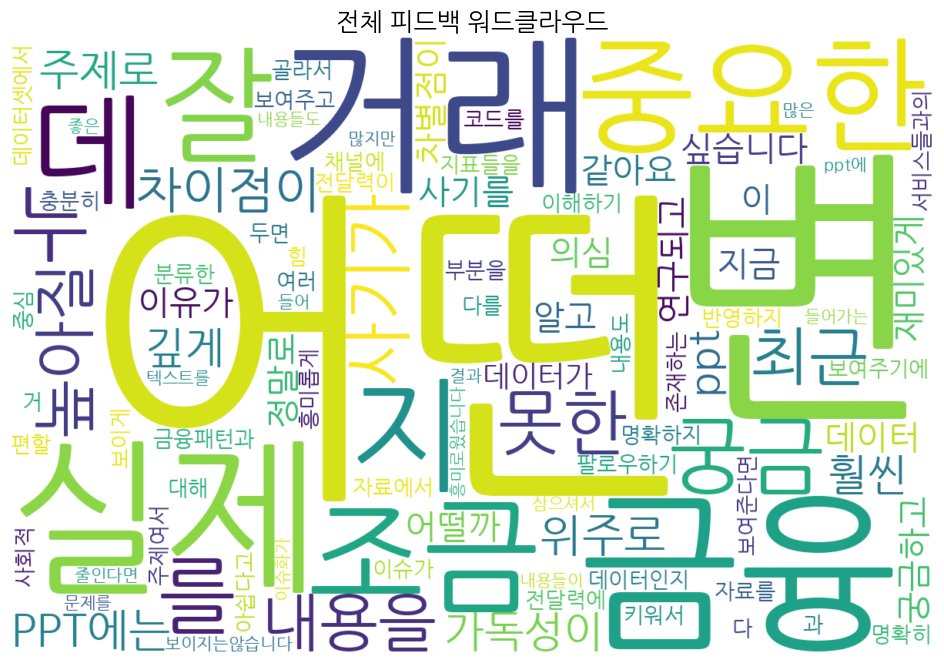

In [ ]:
# =========================
# 12. 전체 피드백 워드클라우드
# =========================

stopwords = [
    "것", "수", "같습니다", "같고", "합니다", "있습니다", "대한", "다만",
    "또한", "더", "좀", "많이", "현재", "기존에", "있는", "되어", "되는",
    "봤습니다", "들었습니다", "좋을", "좋겠습니다", "생각이", "궁금합니다",
    "발표", "프로젝트"
]

text = " ".join(df["feedback"])

for sw in stopwords:
    text = text.replace(sw, " ")

wordcloud = WordCloud(
    font_path=font_path,
    width=1200,
    height=800,
    background_color="white",
    stopwords=set(stopwords),
    max_words=100
).generate(text)

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("전체 피드백 워드클라우드", fontsize=18)
plt.show()

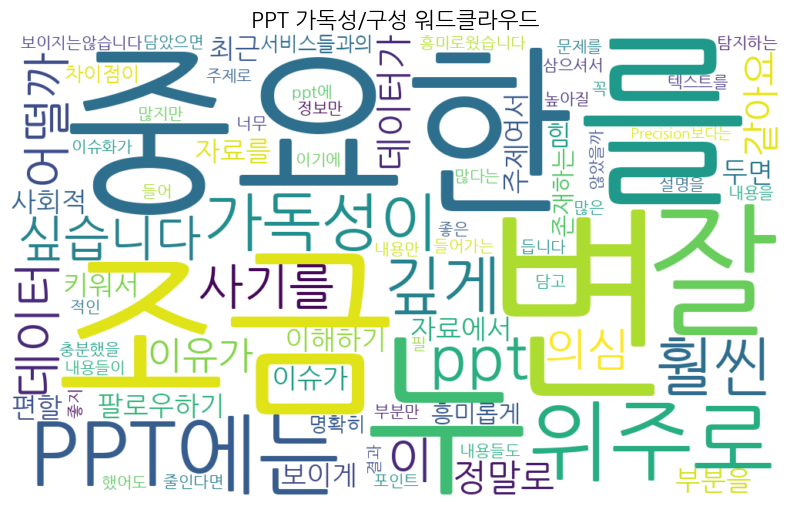

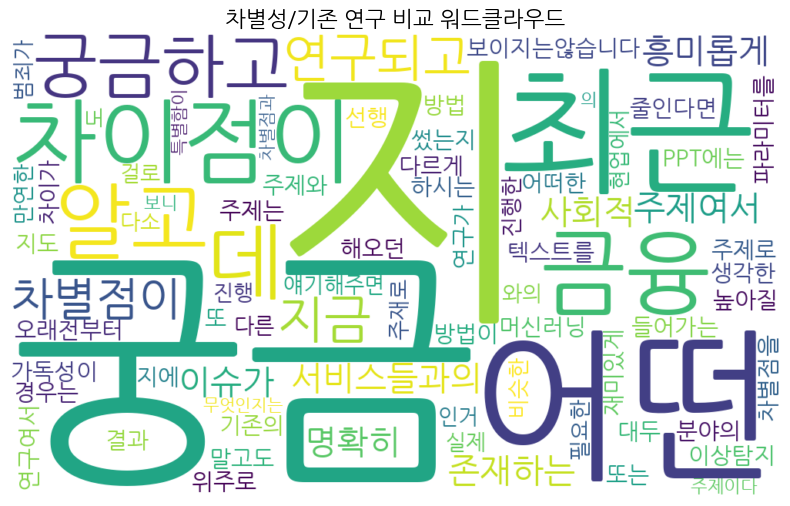

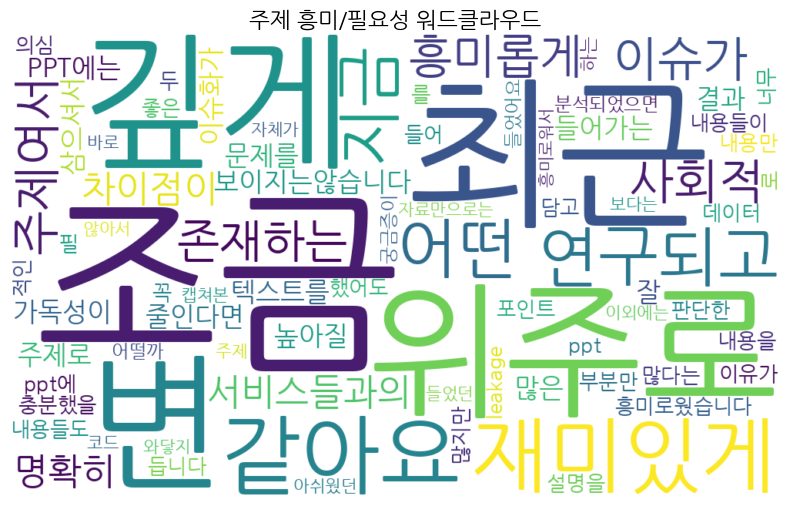

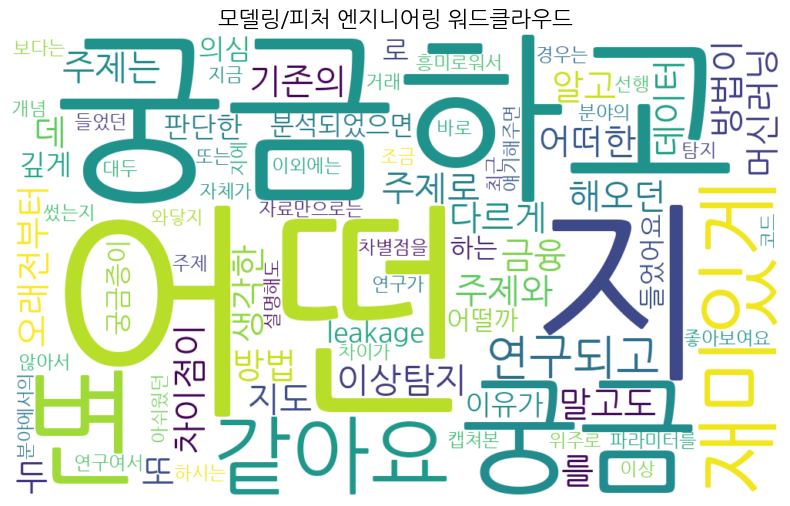

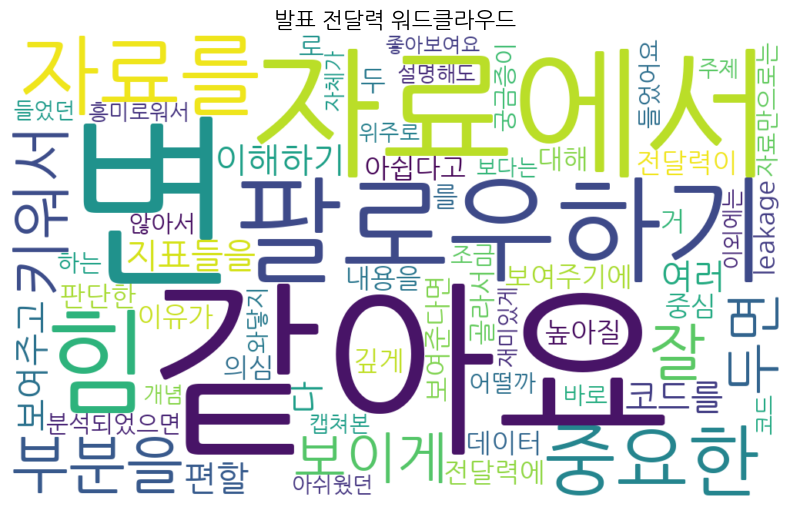

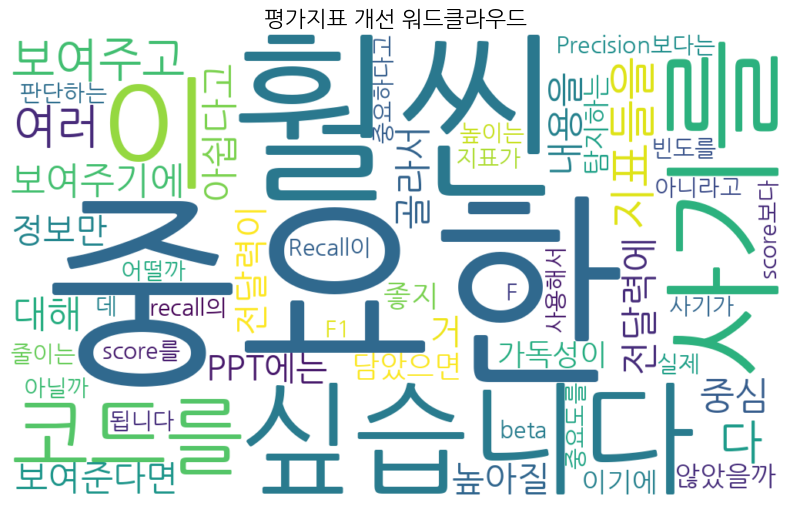

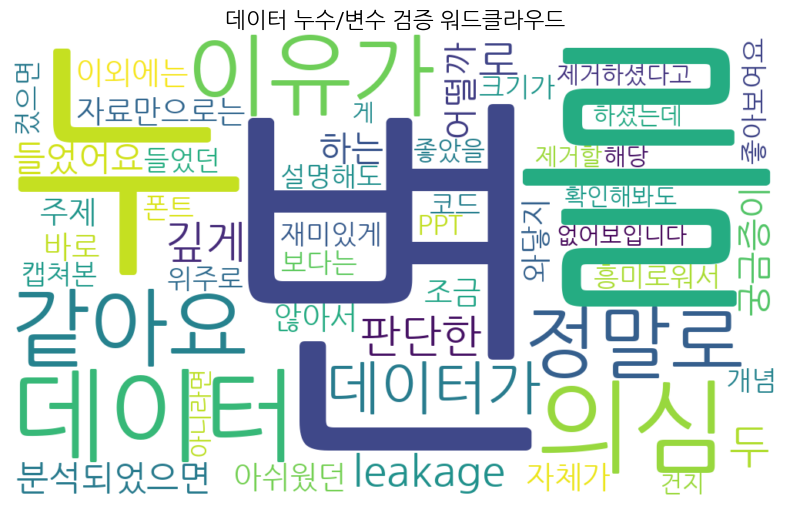

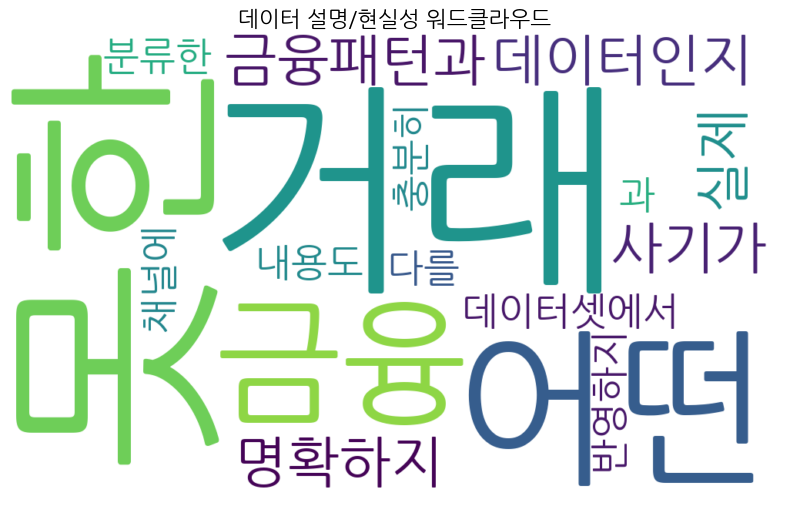

In [ ]:
# =========================
# 13. 토픽별 워드클라우드
# =========================

for topic in topic_count["topic"]:
    topic_text = " ".join(topic_df[topic_df["topic"] == topic]["feedback"])

    for sw in stopwords:
        topic_text = topic_text.replace(sw, " ")

    wc = WordCloud(
        font_path=font_path,
        width=1000,
        height=600,
        background_color="white",
        stopwords=set(stopwords),
        max_words=80
    ).generate(topic_text)

    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"{topic} 워드클라우드", fontsize=16)
    plt.show()

In [ ]:
# =========================
# 14. TF-IDF 기반 주요 키워드 추출
# =========================

custom_stopwords = [
    "것", "수", "같습니다", "생각이", "좋을", "좋겠습니다", "궁금합니다",
    "발표", "프로젝트", "들었습니다", "봤습니다", "대한", "다만",
    "또한", "많이", "되어있는", "현재", "기존에"
]

vectorizer = TfidfVectorizer(
    max_features=100,
    token_pattern=r"(?u)\b\w+\b",
    stop_words=custom_stopwords
)

tfidf_matrix = vectorizer.fit_transform(df["feedback"])
feature_names = np.array(vectorizer.get_feature_names_out())

tfidf_scores = np.asarray(tfidf_matrix.mean(axis=0)).ravel()

keyword_df = pd.DataFrame({
    "keyword": feature_names,
    "tfidf_score": tfidf_scores
}).sort_values("tfidf_score", ascending=False)

keyword_df.head(30)

,keyword,tfidf_score
35,더,0.092045
88,있는지,0.071510
89,잘,0.067984
94,중요한,0.064066
80,어떤,0.064032
27,금융,0.060707
87,있는데,0.060628
79,알고,0.060628
96,차별점이,0.059546
15,거래,0.054888


In [ ]:
# =========================
# 15. 주요 키워드 시각화
# =========================

top_keywords = keyword_df.head(20).sort_values("tfidf_score")

fig = px.bar(
    top_keywords,
    x="tfidf_score",
    y="keyword",
    orientation="h",
    text="tfidf_score",
    title="TF-IDF 기준 주요 키워드 Top 20",
    labels={"tfidf_score": "TF-IDF 점수", "keyword": "키워드"}
)

fig.update_traces(texttemplate="%{text:.3f}")
fig.update_layout(height=600)
fig.show()

In [ ]:
# =========================
# 16. KMeans 기반 자동 토픽 클러스터링
# =========================

n_clusters = 4

vectorizer_cluster = TfidfVectorizer(
    max_features=200,
    token_pattern=r"(?u)\b\w+\b",
    stop_words=custom_stopwords
)

X = vectorizer_cluster.fit_transform(df["feedback"])

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X)

terms = np.array(vectorizer_cluster.get_feature_names_out())
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

cluster_keywords = {}

for i in range(n_clusters):
    top_terms = terms[order_centroids[i, :10]]
    cluster_keywords[i] = list(top_terms)

cluster_result = pd.DataFrame({
    "cluster": list(cluster_keywords.keys()),
    "top_keywords": list(cluster_keywords.values())
})

cluster_result

,cluster,top_keywords
0,0,"[더, 중요한, 이해하기, 자료에서, 부분을, 두면, 보이게, 자료를, 가독성이, ..."
1,1,"[어떤, 지금, 금융, 실제, 있는, 연구되고, 거래, 보니, 무엇인지는, 범죄가]"
2,2,"[있는지, 있는데, 알고, 차별점이, 주재로, 있는걸로, 다른, 비슷한, 궁금하고,..."
3,3,"[조금, 변수를, 내용을, 정말로, 누수되는, 데이터가, 같아요, ppt, 깊게, ..."


In [ ]:
# =========================
# 17. 클러스터별 피드백 확인
# =========================

for cluster_id in sorted(df["cluster"].unique()):
    print("=" * 80)
    print(f"[Cluster {cluster_id}]")
    print("대표 키워드:", cluster_keywords[cluster_id])
    display(df[df["cluster"] == cluster_id][["name", "feedback"]])

[Cluster 0]
대표 키워드: ['더', '중요한', '이해하기', '자료에서', '부분을', '두면', '보이게', '자료를', '가독성이', 'ppt에는']


,name,feedback
1,기민서,발표 자료에서 팔로우하기 힘들었습니다. 자료를 중요한 부분을 키워서 잘 보이게 두면...
3,김진우,최근 이슈가 많이 되는 사회적 주제여서 더 흥미롭게 발표 들었습니다. 다만 기존에 ...
5,박준희,PPT에는 중요한 정보만 담았으면 훨씬 가독성이 좋지 않았을까 싶습니다. 사기를 탐...


[Cluster 1]
대표 키워드: ['어떤', '지금', '금융', '실제', '있는', '연구되고', '거래', '보니', '무엇인지는', '범죄가']


,name,feedback
0,권노현,어떤 금융 거래 데이터인지 명확하지 못한 것 같습니다. 실제 금융패턴과 사기가 데이...
8,이기원,최근 많이 대두되는 분야의 연구여서 재미있게 봤습니다. 기존에 연구되고 있는 또는 ...
11,이호준,금융 범죄가 만연한 지금 필요한 프로젝트인거 같습니다. 다소 실제 현업에서 많이 진...


[Cluster 2]
대표 키워드: ['있는지', '있는데', '알고', '차별점이', '주재로', '있는걸로', '다른', '비슷한', '궁금하고', '오래전부터']


,name,feedback
6,오찬세,"금융 이상탐지 주제는 오래전부터 많이 해오던 주제로 알고 있는데, 기존의 주제와 어..."
9,이채경,"비슷한 주재로 진행한 프로젝트도 있는걸로 알고 있는데, 다른 프로젝트와의 차별점이 ..."
12,장준필,이상 거래 탐지 분야에서의 기존 모델과의 어떤 차별점이 있는지 궁금하고 2개의 모델...


[Cluster 3]
대표 키워드: ['조금', '변수를', '내용을', '정말로', '누수되는', '데이터가', '같아요', 'ppt', '깊게', '데이터']


,name,feedback
2,김정운,"코드를 보여주고, 여러 지표들을 다 보여주기에 전달력에 대해 아쉽다고 생각이 들었습..."
4,김태곤,발표 잘 들었습니다. 현재 많은 이슈화가 되어있는 문제를 주제로 삼으셔서 흥미로웠습...
7,이건우,두 변수를 데이터 leakage 의심 변수로 판단한 이유가 더 깊게 분석되었으면 어...
10,이하영,PPT 폰트 크기가 더 컸으면 좋았을 것 같습니다. 데이터 누수 의심 변수를 제거하...


In [ ]:
# =========================
# 18. LDA 기반 토픽 모델링
# =========================

n_topics = 4

lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method="batch"
)

lda_matrix = lda.fit_transform(X)

lda_topics = []

for topic_idx, topic in enumerate(lda.components_):
    top_indices = topic.argsort()[:-11:-1]
    top_words = terms[top_indices]
    lda_topics.append({
        "topic_id": topic_idx,
        "top_words": list(top_words)
    })

lda_topic_df = pd.DataFrame(lda_topics)
lda_topic_df

,topic_id,top_words
0,0,"[잘, 이해하기, 자료를, 자료에서, 부분을, 두면, 보이게, 조금, 중요한, 더]"
1,1,"[이상탐지, 있는지도, 어떠한, 오래전부터, 주제는, 주제와, 머신러닝, 생각한, ..."
2,2,"[더, 변수를, 정말로, 데이터가, 누수되는, 주재로, 있는걸로, 다른, 비슷한, ..."
3,3,"[어떤, 지금, 실제, 금융, 있는, 연구되고, 거래, 보니, 무엇인지는, 범죄가]"


In [ ]:
# =========================
# 20. 최종 보고서용 요약 테이블 저장
# =========================

final_table = summary_df[[
    "topic",
    "count",
    "priority_score",
    "improvement_action"
]].copy()

final_table.columns = [
    "피드백 토픽",
    "언급 횟수",
    "개선 우선순위 점수",
    "개선 방향"
]

final_table

,피드백 토픽,언급 횟수,개선 우선순위 점수,개선 방향
1,차별성/기존 연구 비교,6,8.4,기존 금융 이상탐지 서비스 및 선행연구와 비교하여 차별점 정리
0,PPT 가독성/구성,6,7.8,"PPT에는 핵심 문장과 결과만 남기고, 코드·긴 설명·세부 지표는 부록으로 이동"
3,모델링/피처 엔지니어링,4,5.2,"모델 수 확대, 이상치 분석, feature engineering 과정 보강"
4,발표 전달력,3,3.6,"중심 메시지를 먼저 제시하고, 코드보다 개념·결과 해석 중심으로 설명"
2,주제 흥미/필요성,5,3.5,금융 범죄 증가와 사회적 필요성을 도입부에서 강조
6,데이터 누수/변수 검증,2,3.0,"Risk_Score, Failed_Transaction_Count_7d 등 누수 의..."
5,평가지표 개선,2,2.8,"Precision, Recall, F1뿐 아니라 Recall 중심의 F-beta s..."
7,데이터 설명/현실성,1,1.2,"데이터셋 출처, 금융 거래 유형, 실제 금융 패턴 반영 한계 명확화"


In [ ]:
# =========================
# 21. CSV 파일로 저장
# =========================

df.to_csv("feedback_raw_data.csv", index=False, encoding="utf-8-sig")
topic_df.to_csv("feedback_topic_mapping.csv", index=False, encoding="utf-8-sig")
final_table.to_csv("feedback_summary_table.csv", index=False, encoding="utf-8-sig")

print("CSV 저장 완료")
print("1. feedback_raw_data.csv")
print("2. feedback_topic_mapping.csv")
print("3. feedback_summary_table.csv")

CSV 저장 완료
1. feedback_raw_data.csv
2. feedback_topic_mapping.csv
3. feedback_summary_table.csv
